Part A - Data Loading and Preprocessing with Scikit-learn

Task 1-Load and Understand the Dataset
Load hotel_bookings.csv. Use head(), shape, info(), describe(), and dtypes.
Check the class distribution of is_canceled and use it as the target y.
Create X from the remaining usable features. Identify numerical and categorical columns.

In [6]:
import pandas as pd
import numpy as np
import os
print(os.path.exists(r"C:\Users\rajab\202618066_Abhikarsh_Raj_DS605\202618066_LAB_3\Data\hotel_bookings.csv"))

True


In [7]:
df = pd.read_csv(r"C:\Users\rajab\202618066_Abhikarsh_Raj_DS605\202618066_LAB_3\Data\hotel_bookings.csv")
print(df.shape)

(119390, 32)


In [8]:
print("="*60)
print("HEAD")
print("="*60)
print(df.head())

HEAD
          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Deposit   
1

In [9]:
print("\n" + "="*60)
print("SHAPE")
print("="*60)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")


SHAPE
Rows: 119390, Columns: 32


In [10]:
print("\n" + "="*60)
print("SHAPE")
print("="*60)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")


SHAPE
Rows: 119390, Columns: 32


In [11]:
print("\n" + "="*60)
print("DESCRIBE (numerical)")
print("="*60)
print(df.describe())
 
print("\n" + "="*60)
print("DESCRIBE (categorical/object)")
print("="*60)
print(df.describe(include='object'))
 
print("\n" + "="*60)
print("DTYPES")
print("="*60)
print(df.dtypes)
 
print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)
print(df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False))
 


DESCRIBE (numerical)
         is_canceled      lead_time  arrival_date_year  \
count  119390.000000  119390.000000      119390.000000   
mean        0.370416     104.011416        2016.156554   
std         0.482918     106.863097           0.707476   
min         0.000000       0.000000        2015.000000   
25%         0.000000      18.000000        2016.000000   
50%         0.000000      69.000000        2016.000000   
75%         1.000000     160.000000        2017.000000   
max         1.000000     737.000000        2017.000000   

       arrival_date_week_number  arrival_date_day_of_month  \
count             119390.000000              119390.000000   
mean                  27.165173                  15.798241   
std                   13.605138                   8.780829   
min                    1.000000                   1.000000   
25%                   16.000000                   8.000000   
50%                   28.000000                  16.000000   
75%                  

C:\Users\rajab\AppData\Local\Temp\ipykernel_26024\435813712.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include='object'))


             hotel arrival_date_month    meal country market_segment  \
count       119390             119390  119390  118902         119390   
unique           2                 12       5     177              8   
top     City Hotel             August      BB     PRT      Online TA   
freq         79330              13877   92310   48590          56477   

       distribution_channel reserved_room_type assigned_room_type  \
count                119390             119390             119390   
unique                    5                 10                 12   
top                   TA/TO                  A                  A   
freq                  97870              85994              74053   

       deposit_type customer_type reservation_status reservation_status_date  
count        119390        119390             119390                  119390  
unique            3             4                  3                     926  
top      No Deposit     Transient          Check-Out    

3. Target variable: is_canceled

In [12]:
print("\n" + "="*60)
print("CLASS DISTRIBUTION: is_canceled")
print("="*60)
print(df['is_canceled'].value_counts())
print("\nProportions:")
print(df['is_canceled'].value_counts(normalize=True).round(4))
 
y = df['is_canceled']
 


CLASS DISTRIBUTION: is_canceled
is_canceled
0    75166
1    44224
Name: count, dtype: int64

Proportions:
is_canceled
0    0.6296
1    0.3704
Name: proportion, dtype: float64


4. Build X — drop target and clearly unusable/leaky columns

In [13]:
leaky_or_id_cols = ['is_canceled', 'reservation_status', 'reservation_status_date']
 
X = df.drop(columns=[c for c in leaky_or_id_cols if c in df.columns])

In [15]:
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'str']).columns.tolist()
 
print("\n" + "="*60)
print("FEATURE TYPES")
print("="*60)
print(f"Numerical columns ({len(numerical_cols)}):\n{numerical_cols}")
print(f"\nCategorical columns ({len(categorical_cols)}):\n{categorical_cols}")
 
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")


FEATURE TYPES
Numerical columns (19):
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical columns (10):
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']

X shape: (119390, 29)
y shape: (119390,)


Task 2 - Missing Values, Leakage, and Outliers
Find the missing-value count and percentage for every column.
Identify columns with very high missingness. Drop them only if justified and state the reason.
Remove columns that directly reveal the final booking outcome, such as reservation_status and reservation_status_date.
Check selected numerical features for outliers using boxplots and/or the IQR method.
Remove only clear/extreme outliers and report how many rows were removed.

In [16]:
import matplotlib.pyplot as plt

1. Missing-value count and percentage for EVERY column

In [19]:
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
 
missing_report = pd.DataFrame({
    'missing_count': missing_count,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)
 
print("="*60)
print("MISSING VALUES — ALL COLUMNS")
print("="*60)
print(missing_report)
print("\n" + "="*60)
print("COLUMNS WITH MISSING VALUES ONLY")
print("="*60)
print(missing_report[missing_report['missing_count'] > 0])
 

MISSING VALUES — ALL COLUMNS
                                missing_count  missing_pct
company                                112593        94.31
agent                                   16340        13.69
country                                   488         0.41
hotel                                       0         0.00
arrival_date_month                          0         0.00
arrival_date_week_number                    0         0.00
lead_time                                   0         0.00
is_canceled                                 0         0.00
stays_in_weekend_nights                     0         0.00
stays_in_week_nights                        0         0.00
children                                    4         0.00
adults                                      0         0.00
babies                                      0         0.00
meal                                        0         0.00
arrival_date_day_of_month                   0         0.00
arrival_date_year          

2. Identify high-missingness columns and drop if justified

In [20]:
HIGH_MISSING_THRESHOLD = 50  # percent
 
high_missing_cols = missing_report[missing_report['missing_pct'] > HIGH_MISSING_THRESHOLD].index.tolist()
print("\n" + "="*60)
print(f"COLUMNS ABOVE {HIGH_MISSING_THRESHOLD}% MISSING (drop candidates)")
print("="*60)
print(high_missing_cols)
 
df_clean = df.drop(columns=high_missing_cols)
print(f"\nDropped {len(high_missing_cols)} column(s) for high missingness: {high_missing_cols}")
print("Reason: at >50% missing, imputation would be mostly fabricated data; "
      "the column carries too little real signal relative to the noise it would add.")
 


COLUMNS ABOVE 50% MISSING (drop candidates)
['company']

Dropped 1 column(s) for high missingness: ['company']
Reason: at >50% missing, imputation would be mostly fabricated data; the column carries too little real signal relative to the noise it would add.


 3. Remove columns that leak the target (final booking outcome)

In [21]:
leak_cols = ['reservation_status', 'reservation_status_date']
leak_cols_present = [c for c in leak_cols if c in df_clean.columns]
 
df_clean = df_clean.drop(columns=leak_cols_present)
print("\n" + "="*60)
print("LEAKAGE COLUMNS REMOVED")
print("="*60)
print(f"Removed: {leak_cols_present}")
print("Reason: 'reservation_status' directly encodes whether a booking was "
      "Canceled/Checked-Out/No-Show — this IS the target restated, and "
      "'reservation_status_date' is only populated once the outcome is known "
      "(a booking made today can't have a status date from the future). "
      "Both cause target leakage if kept.")


LEAKAGE COLUMNS REMOVED
Removed: ['reservation_status', 'reservation_status_date']
Reason: 'reservation_status' directly encodes whether a booking was Canceled/Checked-Out/No-Show — this IS the target restated, and 'reservation_status_date' is only populated once the outcome is known (a booking made today can't have a status date from the future). Both cause target leakage if kept.


4. Outlier check — boxplots + IQR method

In [22]:
numerical_outlier_cols = ['lead_time', 'adr', 'stays_in_weekend_nights',
                           'stays_in_week_nights', 'adults', 'babies']
numerical_outlier_cols = [c for c in numerical_outlier_cols if c in df_clean.columns]
 
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(numerical_outlier_cols):
    axes[i].boxplot(df_clean[col].dropna())
    axes[i].set_title(col)
plt.tight_layout()
plt.savefig('outlier_boxplots.png', dpi=100)
plt.close()
print("\nBoxplots saved to outlier_boxplots.png")
 
# IQR method
def iqr_bounds(series, k=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - k * IQR
    upper = Q3 + k * IQR
    return lower, upper
 
print("\n" + "="*60)
print("IQR OUTLIER BOUNDS AND COUNTS")
print("="*60)
outlier_summary = {}
for col in numerical_outlier_cols:
    lower, upper = iqr_bounds(df_clean[col])
    n_outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    outlier_summary[col] = {'lower': lower, 'upper': upper, 'n_outliers': n_outliers,
                             'pct_outliers': round(n_outliers / len(df_clean) * 100, 2)}
    print(f"{col:30s} | bounds=({lower:.1f}, {upper:.1f}) | "
          f"outliers={n_outliers} ({outlier_summary[col]['pct_outliers']}%)")


Boxplots saved to outlier_boxplots.png

IQR OUTLIER BOUNDS AND COUNTS
lead_time                      | bounds=(-195.0, 373.0) | outliers=3005 (2.52%)
adr                            | bounds=(-15.8, 211.1) | outliers=3793 (3.18%)
stays_in_weekend_nights        | bounds=(-3.0, 5.0) | outliers=265 (0.22%)
stays_in_week_nights           | bounds=(-2.0, 6.0) | outliers=3354 (2.81%)
adults                         | bounds=(2.0, 2.0) | outliers=29710 (24.88%)
babies                         | bounds=(0.0, 0.0) | outliers=917 (0.77%)


5. Remove only CLEAR/EXTREME outliers (not the full IQR fence —

In [24]:
rows_before = len(df_clean)
 
extreme_conditions = pd.Series(True, index=df_clean.index)
 
if 'adr' in df_clean.columns:
    # ADR (average daily rate): negative or absurdly high (>5000) is implausible
    extreme_conditions &= (df_clean['adr'] >= 0) & (df_clean['adr'] < 5000)
 
if 'lead_time' in df_clean.columns:
    # Lead time > 500 days (~1.5 yrs ahead) is extremely rare but keep unless truly extreme
    extreme_conditions &= (df_clean['lead_time'] <= 700)
 
if 'adults' in df_clean.columns:
    # More than 10 adults on one booking is implausible for standard bookings
    extreme_conditions &= (df_clean['adults'] <= 10)
 
if 'babies' in df_clean.columns:
    # More than 5 babies is implausible / data-entry error
    extreme_conditions &= (df_clean['babies'] <= 5)
 
df_clean = df_clean[extreme_conditions]
rows_after = len(df_clean)
rows_removed = rows_before - rows_after
 
print("\n" + "="*60)
print("EXTREME OUTLIER REMOVAL SUMMARY")
print("="*60)
print(f"Rows before: {rows_before}")
print(f"Rows after:  {rows_after}")
print(f"Rows removed: {rows_removed} ({rows_removed/rows_before*100:.2f}%)")
print("\nCriteria used (domain-informed hard caps, not the full IQR fence, "
      "since strict IQR would remove too many legitimate high-lead-time / "
      "high-ADR bookings which are real, just rare):")
print("  - adr: kept only 0 <= adr < 5000 (removes negative/erroneous fares)")
print("  - lead_time: kept only <= 700 days")
print("  - adults: kept only <= 10")
print("  - babies: kept only <= 5")
 
print(f"\nFinal shape after Task 2 cleaning: {df_clean.shape}")


EXTREME OUTLIER REMOVAL SUMMARY
Rows before: 119390
Rows after:  119372
Rows removed: 18 (0.02%)

Criteria used (domain-informed hard caps, not the full IQR fence, since strict IQR would remove too many legitimate high-lead-time / high-ADR bookings which are real, just rare):
  - adr: kept only 0 <= adr < 5000 (removes negative/erroneous fares)
  - lead_time: kept only <= 700 days
  - adults: kept only <= 10
  - babies: kept only <= 5

Final shape after Task 2 cleaning: (119372, 29)


In [ ]:
Task 3 - Create Two Preprocessing Pipelines
Split the data using train_test_split(test_size=0.2, stratify-y, random_state=42). Use the same split for all experiments.
For numerical columns, use KNNImputer(n_neighbors=5) for missing values.
For categorical columns, use SimpleImputer(strategy="most_frequent") and OneHotEncoder(handle_unknown="ignore").
Pipeline A: KNNImputer + StandardScaler for numerical features.
Pipeline B: KNNImputer + MinMaxScaler for numerical features.
Use Column Transformer and Pipeline so that preprocessing is fitted only on the training data.

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

1. Train/test split — SAME split used for every experiment

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
 
print("="*60)
print("TRAIN/TEST SPLIT")
print("="*60)
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train distribution:\n{y_train.value_counts(normalize=True).round(4)}")
print(f"y_test distribution:\n{y_test.value_counts(normalize=True).round(4)}")

TRAIN/TEST SPLIT
X_train: (95512, 29), X_test: (23878, 29)
y_train distribution:
is_canceled
0    0.6296
1    0.3704
Name: proportion, dtype: float64
y_test distribution:
is_canceled
0    0.6296
1    0.3704
Name: proportion, dtype: float64


2. Identify numerical and categorical columns from X_train

In [28]:
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'str']).columns.tolist()
 
print(f"\nNumerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")
 


Numerical columns (19): ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
Categorical columns (10): ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']


3. Categorical transformer — shared by both pipelines

In [29]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

4. PIPELINE A — KNNImputer + StandardScaler (numerical)

In [30]:
numerical_transformer_A = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])
 
preprocessor_A = ColumnTransformer(transformers=[
    ('num', numerical_transformer_A, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])
 
pipeline_A = Pipeline(steps=[
    ('preprocessor', preprocessor_A)
])

5. PIPELINE B — KNNImputer + MinMaxScaler (numerical)

In [31]:
numerical_transformer_B = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', MinMaxScaler())
])
 
preprocessor_B = ColumnTransformer(transformers=[
    ('num', numerical_transformer_B, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])
 
pipeline_B = Pipeline(steps=[
    ('preprocessor', preprocessor_B)
])
 

6. Fit ONLY on training data, then transform train and test

In [33]:
X_train_A = pipeline_A.fit_transform(X_train)
X_test_A = pipeline_A.transform(X_test)
 
X_train_B = pipeline_B.fit_transform(X_train)
X_test_B = pipeline_B.transform(X_test)
 
print("\n" + "="*60)
print("PIPELINE A (StandardScaler) OUTPUT SHAPES")
print("="*60)
print(f"X_train_A: {X_train_A.shape}")
print(f"X_test_A:  {X_test_A.shape}")
 
print("\n" + "="*60)
print("PIPELINE B (MinMaxScaler) OUTPUT SHAPES")
print("="*60)
print(f"X_train_B: {X_train_B.shape}")
print(f"X_test_B:  {X_test_B.shape}")


PIPELINE A (StandardScaler) OUTPUT SHAPES
X_train_A: (95512, 252)
X_test_A:  (23878, 252)

PIPELINE B (MinMaxScaler) OUTPUT SHAPES
X_train_B: (95512, 252)
X_test_B:  (23878, 252)


In [34]:
feature_names_A = pipeline_A.named_steps['preprocessor'].get_feature_names_out()
print(f"\nTotal features after preprocessing (Pipeline A): {len(feature_names_A)}")


Total features after preprocessing (Pipeline A): 252


# Part B - Model Training and Performance Evaluation.

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [36]:
# --- Combination 1: Logistic Regression + Pipeline A (StandardScaler) ---
model_LR_A = Pipeline(steps=[
    ('preprocessor', preprocessor_A),
    ('classifier', LogisticRegression(max_iter=1000))
])
 
# --- Combination 2: Logistic Regression + Pipeline B (MinMaxScaler) ---
model_LR_B = Pipeline(steps=[
    ('preprocessor', preprocessor_B),
    ('classifier', LogisticRegression(max_iter=1000))
])
 
# --- Combination 3: Decision Tree + Pipeline A (StandardScaler) ---
model_DT_A = Pipeline(steps=[
    ('preprocessor', preprocessor_A),
    ('classifier', DecisionTreeClassifier(random_state=42))
])
 
# --- Combination 4: Decision Tree + Pipeline B (MinMaxScaler) ---
model_DT_B = Pipeline(steps=[
    ('preprocessor', preprocessor_B),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

Train all four on the SAME train split

In [38]:
print("Training Logistic Regression + Pipeline A ...")
model_LR_A.fit(X_train, y_train)
 
print("Training Logistic Regression + Pipeline B ...")
model_LR_B.fit(X_train, y_train)
 
print("Training Decision Tree + Pipeline A ...")
model_DT_A.fit(X_train, y_train)
 
print("Training Decision Tree + Pipeline B ...")
model_DT_B.fit(X_train, y_train)
 
print("\nAll 4 model-pipeline combinations trained successfully.")

Training Logistic Regression + Pipeline A ...
Training Logistic Regression + Pipeline B ...
Training Decision Tree + Pipeline A ...
Training Decision Tree + Pipeline B ...

All 4 model-pipeline combinations trained successfully.


Quick sanity check — training accuracy for each

In [39]:
models = {
    'LogisticRegression + Pipeline A (Standard)': model_LR_A,
    'LogisticRegression + Pipeline B (MinMax)':   model_LR_B,
    'DecisionTree + Pipeline A (Standard)':       model_DT_A,
    'DecisionTree + Pipeline B (MinMax)':         model_DT_B,
}
 
print("\n" + "="*60)
print("TRAINING ACCURACY (sanity check only — not final evaluation)")
print("="*60)
for name, model in models.items():
    train_acc = model.score(X_train, y_train)
    print(f"{name:45s} | train acc = {train_acc:.4f}")


TRAINING ACCURACY (sanity check only — not final evaluation)
LogisticRegression + Pipeline A (Standard)    | train acc = 0.8185
LogisticRegression + Pipeline B (MinMax)      | train acc = 0.8136
DecisionTree + Pipeline A (Standard)          | train acc = 0.9963
DecisionTree + Pipeline B (MinMax)            | train acc = 0.9963


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

# ---------------------------------------------------------
# (Assumes from Task 4: model_LR_A, model_LR_B, model_DT_A, model_DT_B
#  all already trained; and X_train, X_test, y_train, y_test from Task 3)
# ---------------------------------------------------------

models = {
    'LogReg + StandardScaler (A)': model_LR_A,
    'LogReg + MinMaxScaler (B)':   model_LR_B,
    'DecisionTree + StandardScaler (A)': model_DT_A,
    'DecisionTree + MinMaxScaler (B)':   model_DT_B,
}

In [42]:
# ===========================================================
# 1. Compute train acc, test acc, precision, recall, F1 for each
# ===========================================================
results = []

for name, model in models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)

    results.append({
        'Model-Pipeline': name,
        'Train Accuracy': round(train_acc, 4),
        'Test Accuracy': round(test_acc, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1-Score': round(f1, 4),
        'Train-Test Gap': round(train_acc - test_acc, 4)
    })

In [43]:


# ===========================================================
# 2. Final comparison table
# ===========================================================
comparison_df = pd.DataFrame(results)
print("="*100)
print("FINAL COMPARISON TABLE — ALL FOUR MODEL-PIPELINE COMBINATIONS")
print("="*100)
print(comparison_df.to_string(index=False))

comparison_df.to_csv('model_comparison_results.csv', index=False)
print("\nSaved to model_comparison_results.csv")



FINAL COMPARISON TABLE — ALL FOUR MODEL-PIPELINE COMBINATIONS
                   Model-Pipeline  Train Accuracy  Test Accuracy  Precision  Recall  F1-Score  Train-Test Gap
      LogReg + StandardScaler (A)          0.8185         0.8188     0.8103  0.6669    0.7317         -0.0002
        LogReg + MinMaxScaler (B)          0.8136         0.8145     0.8095  0.6529    0.7228         -0.0010
DecisionTree + StandardScaler (A)          0.9963         0.8575     0.8058  0.8109    0.8083          0.1388
  DecisionTree + MinMaxScaler (B)          0.9963         0.8576     0.8057  0.8111    0.8084          0.1388

Saved to model_comparison_results.csv


In [44]:
# ===========================================================
# 3. Identify best Logistic Regression and best Decision Tree
#    ("best" = highest Test Accuracy within each model family)
# ===========================================================
lr_rows = comparison_df[comparison_df['Model-Pipeline'].str.contains('LogReg')]
dt_rows = comparison_df[comparison_df['Model-Pipeline'].str.contains('DecisionTree')]

best_lr_name = lr_rows.loc[lr_rows['Test Accuracy'].idxmax(), 'Model-Pipeline']
best_dt_name = dt_rows.loc[dt_rows['Test Accuracy'].idxmax(), 'Model-Pipeline']

best_lr_model = models[best_lr_name]
best_dt_model = models[best_dt_name]

print(f"\nBest Logistic Regression combo: {best_lr_name}")
print(f"Best Decision Tree combo:       {best_dt_name}")




Best Logistic Regression combo: LogReg + StandardScaler (A)
Best Decision Tree combo:       DecisionTree + MinMaxScaler (B)


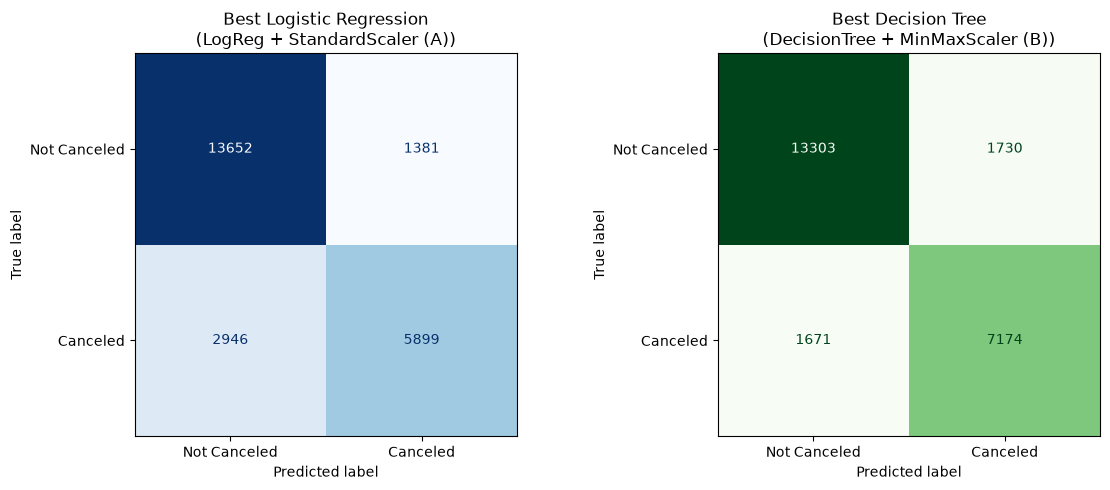


Confusion matrices saved to confusion_matrices_best_models.png


In [45]:
# ===========================================================
# 4. Confusion matrices for the two best models
# ===========================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

y_pred_lr = best_lr_model.predict(X_test)
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Not Canceled', 'Canceled'])
disp_lr.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Best Logistic Regression\n({best_lr_name})')

y_pred_dt = best_dt_model.predict(X_test)
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Not Canceled', 'Canceled'])
disp_dt.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title(f'Best Decision Tree\n({best_dt_name})')

plt.tight_layout()
plt.savefig('confusion_matrices_best_models.png', dpi=100)
plt.show()
print("\nConfusion matrices saved to confusion_matrices_best_models.png")



In [46]:
# ===========================================================
# 5. Overfitting commentary based on train-test gap
# ===========================================================
print("\n" + "="*60)
print("OVERFITTING ANALYSIS (based on Train-Test Accuracy Gap)")
print("="*60)
for row in results:
    gap = row['Train-Test Gap']
    name = row['Model-Pipeline']
    if gap > 0.10:
        verdict = "Likely OVERFITTING — large train-test gap"
    elif gap > 0.03:
        verdict = "Mild overfitting — moderate gap"
    else:
        verdict = "Good generalization — small gap"
    print(f"{name:40s} | gap={gap:.4f} | {verdict}")

print("\nGeneral expectation for this dataset:")
print("- Decision Tree (unconstrained, no max_depth) typically shows the largest")
print("  train-test gap since it can grow deep enough to memorize training data.")
print("- Logistic Regression, being a simpler linear model, usually generalizes")
print("  more consistently with a smaller train-test gap.")
print("- Scaler choice (Standard vs MinMax) should barely affect the Decision")
print("  Tree's gap, since trees are scale-invariant; it mainly affects LogReg.")


OVERFITTING ANALYSIS (based on Train-Test Accuracy Gap)
LogReg + StandardScaler (A)              | gap=-0.0002 | Good generalization — small gap
LogReg + MinMaxScaler (B)                | gap=-0.0010 | Good generalization — small gap
DecisionTree + StandardScaler (A)        | gap=0.1388 | Likely OVERFITTING — large train-test gap
DecisionTree + MinMaxScaler (B)          | gap=0.1388 | Likely OVERFITTING — large train-test gap

General expectation for this dataset:
- Decision Tree (unconstrained, no max_depth) typically shows the largest
  train-test gap since it can grow deep enough to memorize training data.
- Logistic Regression, being a simpler linear model, usually generalizes
  more consistently with a smaller train-test gap.
- Scaler choice (Standard vs MinMax) should barely affect the Decision
  Tree's gap, since trees are scale-invariant; it mainly affects LogReg.
